In [1]:
"""
Data Pre‑processing, Modeling, and Evaluation

This section transforms the cleaned, feature‑enriched wildfire dataset into
model‑ready input, trains three supervised‑learning classifiers, and evaluates
their performance.

──────────────────────────────────────────────────────────
1.  Data Pre‑processing
──────────────────────────────────────────────────────────
•  Type casting & validation
   - All predictive features (`temp_c`, `humidity`, `wind_kph`,
     `NDVI`, `UTILITYMISCSTRUCTUREDISTANCE`) are coerced to float64.

•  Missing‑value handling
   - Numerical gaps are imputed with the median of each column
     to preserve central tendency while remaining robust to outliers.

•  Temporal train–test split
   - Records dated **before 2021** → **training set**
   - Records dated **2021 – 2024** → **test set**
   - This date‑wise rule maintains temporal causality for a realistic
     “train on the past, predict the future” scenario.

•  Class‑imbalance treatment
   - `SMOTE` (Synthetic Minority Oversampling Technique) is applied
     only to the training set to generate synthetic examples for
     under‑represented damage categories and avoid data leakage.

•  Target encoding
   - The categorical `* Damage` field is label‑encoded to integer classes
     for model compatibility.

──────────────────────────────────────────────────────────
2.  Modeling
──────────────────────────────────────────────────────────
Three multiclass classifiers are trained and compared:

A. Random Forest  
   • Hyperparameters tuned via `GridSearchCV`  
     – `n_estimators`, `max_depth`, `min_samples_split`  
   • Suitable for tabular data with non‑linear relationships.  

B. XGBoost  
   • Objective set to `'multi:softprob'`.  
   • Grid search over `n_estimators`, `max_depth`, `learning_rate`.  
   • Class weights / sample weights passed to mitigate residual imbalance.  

C. Gaussian Naive Bayes (baseline)  
   • Only `var_smoothing` is tuned on a log‑spaced grid.  
   • Provides a fast probabilistic benchmark.  

Cross‑validation inside each grid search uses three folds
and optimizes the **macro‑averaged F1‑score**.

──────────────────────────────────────────────────────────
3.  Evaluation Metrics
──────────────────────────────────────────────────────────
• **Precision (Macro)** – proportion of correct positive predictions averaged
  equally across classes.  
• **F1‑Score (Macro)** – harmonic mean of precision and recall
  (class‑balanced).  
• **ROC‑AUC (Macro)** – area under the one‑vs‑rest ROC curve, averaged across
  classes.  
• **Accuracy** (optional) – reported but interpreted cautiously due to class
  imbalance.

ROC curves for all three models are plotted on a single figure; class‑wise ROC
curves are provided in a separate visualization.  SHAP (`TreeExplainer`) is
used on the best‑performing model (Random Forest) to interpret feature impact.

──────────────────────────────────────────────────────────
Output
──────────────────────────────────────────────────────────
The notebook returns:
• Tuned model objects (`best_rf`, `best_xgb`, `best_nb`).  
• A comparative metrics table (precision, F1, ROC‑AUC).  
• ROC plots and SHAP summary/force plots for interpretability.  

This end‑to‑end pipeline readies the project for deployment scenarios and forms
the basis for the results and analysis presented in the report.
"""


"\nData\u202fPre‑processing, Modeling, and Evaluation\n\nThis section transforms the cleaned, feature‑enriched wildfire dataset into\nmodel‑ready input, trains three supervised‑learning classifiers, and evaluates\ntheir performance.\n\n──────────────────────────────────────────────────────────\n1.  Data\u202fPre‑processing\n──────────────────────────────────────────────────────────\n•  Type casting & validation\n   - All predictive features (`temp_c`, `humidity`, `wind_kph`,\n     `NDVI`, `UTILITYMISCSTRUCTUREDISTANCE`) are coerced to float64.\n\n•  Missing‑value handling\n   - Numerical gaps are imputed with the median of each column\n     to preserve central tendency while remaining robust to outliers.\n\n•  Temporal train–test split\n   - Records dated **before\u202f2021** → **training set**\n   - Records dated **2021\u202f–\u202f2024** → **test set**\n   - This date‑wise rule maintains temporal causality for a realistic\n     “train on the past, predict the future” scenario.\n\n•  

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, precision_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [7]:
# List of feature columns
features = ['temp_c', 'humidity', 'wind_kph', 'NDVI', 'utility_distance']

# Convert all to float64 (numeric format)
df[features] = df[features].astype('float64')

# Optional: verify
print(df[features].dtypes)


temp_c              float64
humidity            float64
wind_kph            float64
NDVI                float64
utility_distance    float64
dtype: object


In [5]:
# Load dataset
df = pd.read_csv("Wildfire_Cleaned_With_Weather_NDVI.csv")
df["Incident Start Date"] = pd.to_datetime(df["Incident Start Date"], errors='coerce')
df = df.dropna(subset=["Incident Start Date", "* Damage"])

# Define features and target
features = ['temp_c', 'humidity', 'wind_kph', 'NDVI', 'utility_distance']
df[features] = df[features].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=features)

# Encode target
label_encoder = LabelEncoder()
df["damage_encoded"] = label_encoder.fit_transform(df["* Damage"])
classes = label_encoder.classes_


C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_15336\1384471627.py:2: DtypeWarning: Columns (14,38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Wildfire_Cleaned_With_Weather_NDVI.csv")


In [9]:
# Split into train (before 2021) and test (2021–2024)
train_df = df[df["Incident Start Date"].dt.year < 2021]
test_df = df[df["Incident Start Date"].dt.year >= 2021]

X_train, y_train = train_df[features], train_df["damage_encoded"]
X_test, y_test = test_df[features], test_df["damage_encoded"]


In [11]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Assume you have already defined:
# X_train, y_train from your earlier date-based split
# And all features are numeric and cleaned

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Optional: check class distribution after SMOTE
from collections import Counter
print("Class distribution after SMOTE:", Counter(y_train_resampled))


Class distribution after SMOTE: Counter({5: 48190, 0: 48190, 4: 48190, 1: 48190, 3: 48190, 2: 48190})


In [13]:
rf = RandomForestClassifier(random_state=42, class_weight="balanced")
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(rf, param_grid_rf, scoring='f1_macro', cv=3, n_jobs=-1)
grid_rf.fit(X_train_resampled, y_train_resampled)
best_rf = grid_rf.best_estimator_


In [49]:

xgb = XGBClassifier(objective='multi:softprob', num_class=len(classes), eval_metric='mlogloss', use_label_encoder=False, random_state=42, scale_pos_weight=weight_dict)
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.01]
}
grid_xgb = GridSearchCV(xgb, param_grid_xgb, scoring='f1_macro', cv=3, n_jobs=-1)
grid_xgb.fit(X_train_resampled, y_train_resampled)
best_xgb = grid_xgb.best_estimator_


Class weights for XGBoost: {5: 0.5328896121960719, 0: 4.3599066803232045, 4: 14.918419003115265, 1: 0.26499619561458115, 3: 27.88245997088792, 2: 57.00967261904762}


D:\Coderboimolly\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:55:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [59]:
from sklearn.metrics import precision_score, f1_score

y_pred_rf = best_rf.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

precision_rf = precision_score(y_test, y_pred_rf, average='macro')
f1_rf = f1_score(y_test, y_pred_rf, average='macro')

precision_xgb = precision_score(y_test, y_pred_xgb, average='macro')
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')

# Print scores in tabular format
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Precision": [precision_rf, precision_xgb],
    "F1 Score": [f1_rf, f1_xgb]
})
print(results)


           Model  Precision  F1 Score
0  Random Forest   0.178976  0.163539
1        XGBoost   0.189099  0.100799


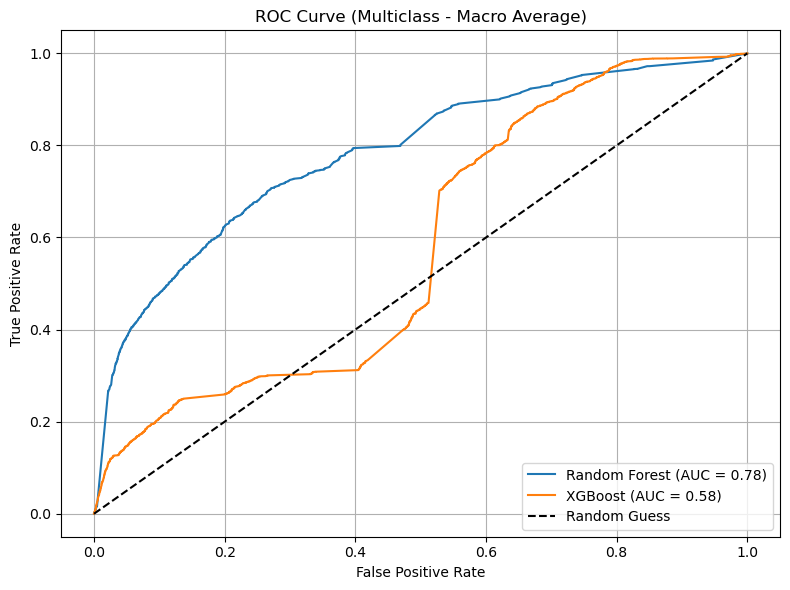

In [55]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize target
y_test_bin = label_binarize(y_test, classes=range(len(classes)))
y_score_rf = best_rf.predict_proba(X_test)
y_score_xgb = best_xgb.predict_proba(X_test)

# Plot ROC for each model (macro average)
fpr_rf, tpr_rf, _ = roc_curve(y_test_bin.ravel(), y_score_rf.ravel())
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_bin.ravel(), y_score_xgb.ravel())

roc_auc_rf = auc(fpr_rf, tpr_rf)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multiclass - Macro Average)')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()


In [57]:
from sklearn.metrics import accuracy_score

# Example: for Random Forest
y_pred_rf = best_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

# Example: for XGBoost
y_pred_xgb = best_xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")


Random Forest Accuracy: 0.4889
XGBoost Accuracy: 0.2096


In [61]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, precision_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import label_binarize


In [63]:
# Define model and parameter grid
nb = GaussianNB()
param_grid_nb = {'var_smoothing': np.logspace(-9, -6, 5)}

# Grid search
grid_nb = GridSearchCV(nb, param_grid_nb, scoring='f1_macro', cv=3)
grid_nb.fit(X_train, y_train)
best_nb = grid_nb.best_estimator_


In [65]:
y_pred_nb = best_nb.predict(X_test)
f1_nb = f1_score(y_test, y_pred_nb, average='macro')
precision_nb = precision_score(y_test, y_pred_nb, average='macro')

print(f"Naive Bayes F1 Score: {f1_nb:.4f}")
print(f"Naive Bayes Precision: {precision_nb:.4f}")


Naive Bayes F1 Score: 0.0309
Naive Bayes Precision: 0.2128


D:\Coderboimolly\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


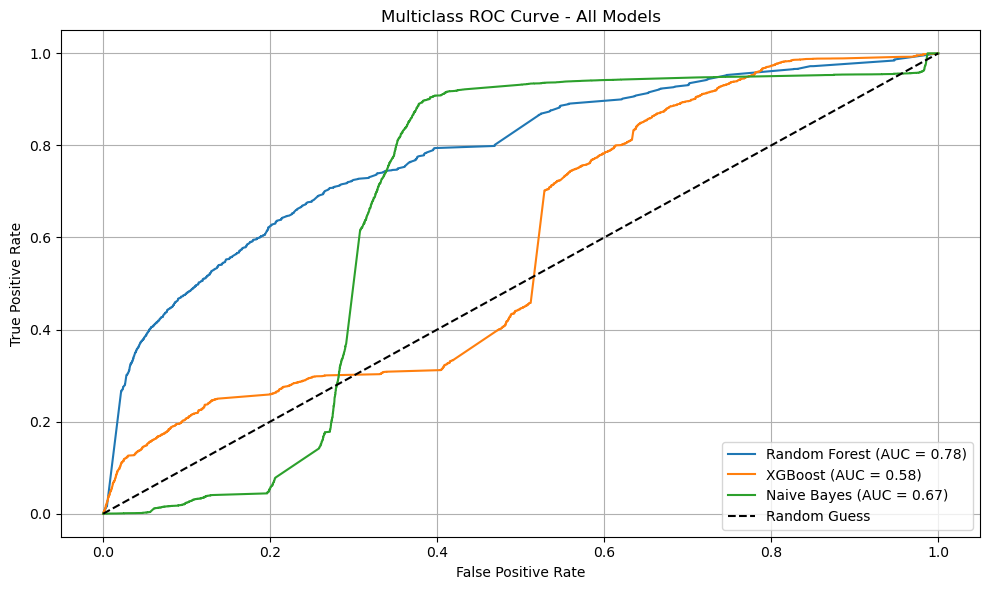

In [67]:
# Binarize the output for ROC
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# Predicted probabilities
y_score_rf = best_rf.predict_proba(X_test)
y_score_xgb = best_xgb.predict_proba(X_test)
y_score_nb = best_nb.predict_proba(X_test)

# Compute macro-average ROC for each model
fpr_rf, tpr_rf, _ = roc_curve(y_test_bin.ravel(), y_score_rf.ravel())
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_bin.ravel(), y_score_xgb.ravel())
fpr_nb, tpr_nb, _ = roc_curve(y_test_bin.ravel(), y_score_nb.ravel())

roc_auc_rf = auc(fpr_rf, tpr_rf)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

# Plot all ROC curves together
plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.title('Multiclass ROC Curve - All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()


In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Load your feature matrix (X_test) and trained Random Forest model
# Ensure X_test uses same columns/features used in training

# Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_test)

# Plot summary (global interpretability)
plt.title("SHAP Summary Plot - Random Forest")
shap.summary_plot(shap_values, X_test, plot_type="bar")
